In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.7 MB/s eta 0:00:00


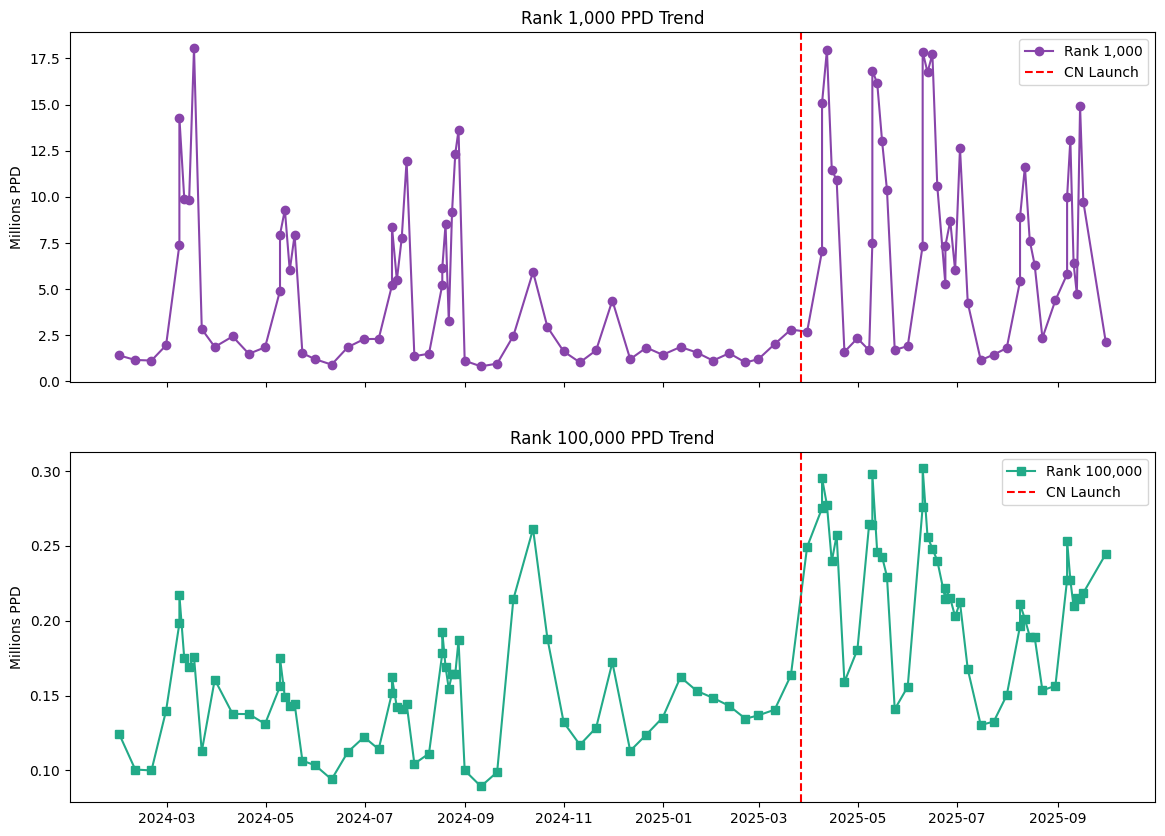

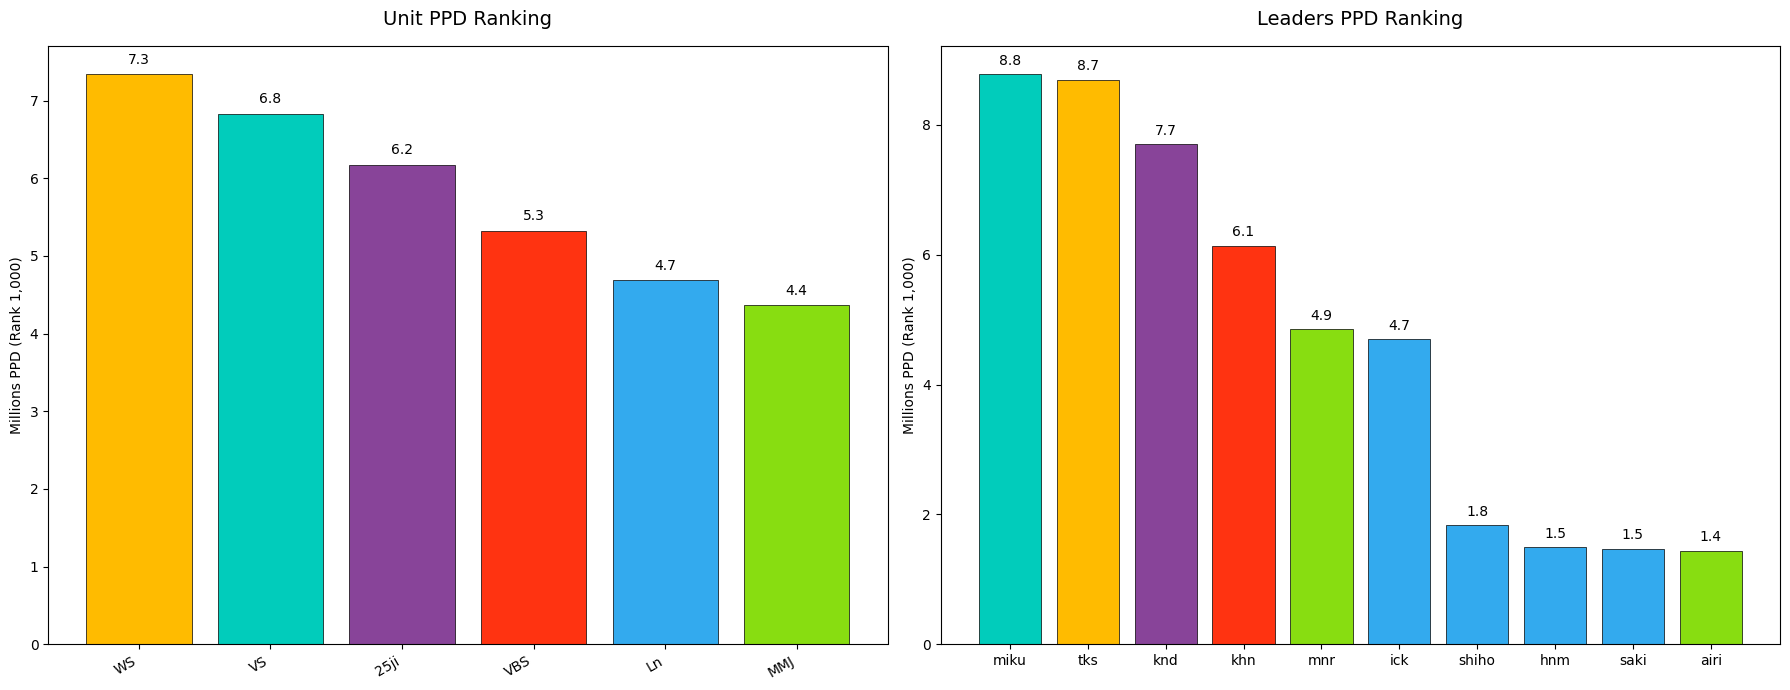

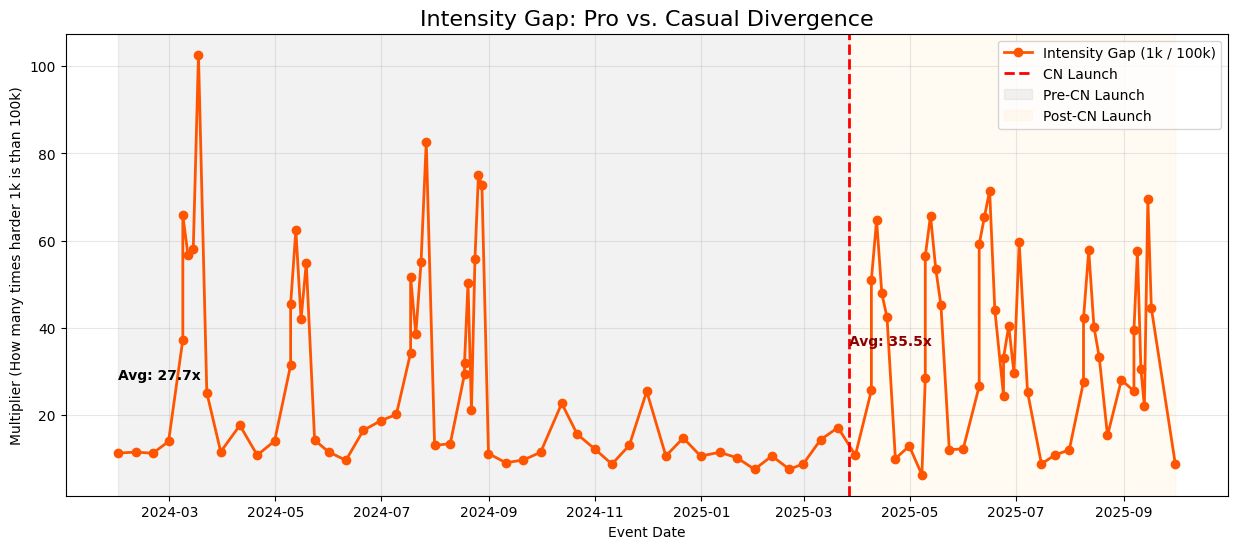

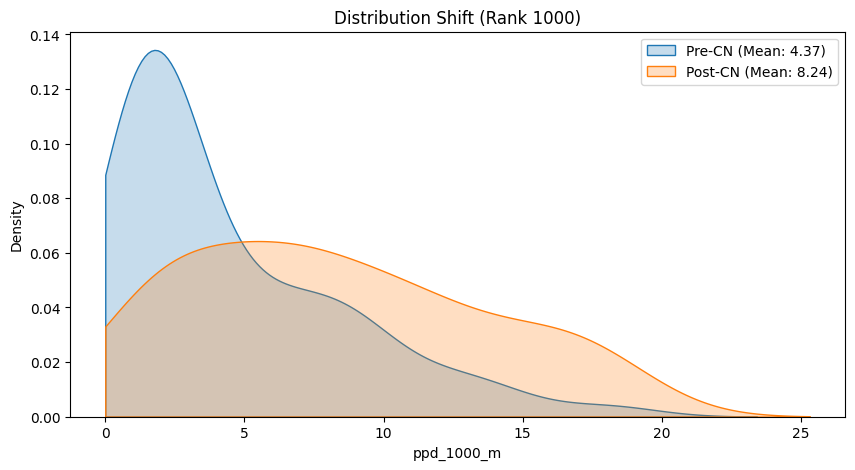

Rank 1000 T-test P-Value: 0.0000970611


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


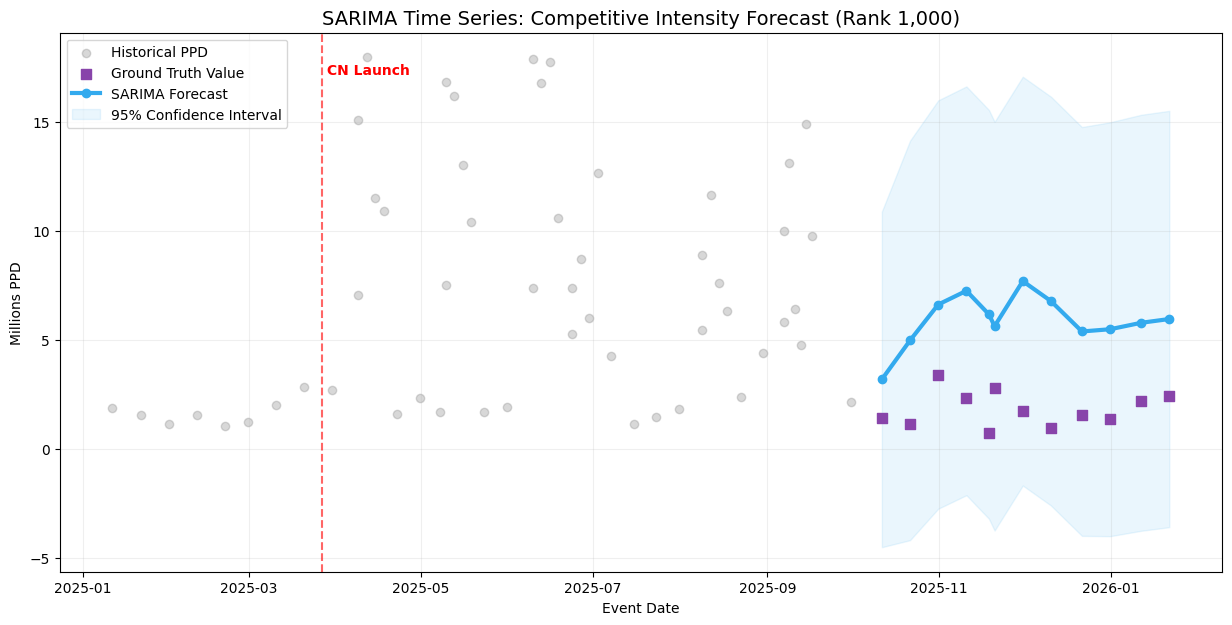

--- SARIMA Summary ---
Best Model Order: (2, 0, 0)
Seasonal Order: (0, 0, 1, 9)
Model AIC: 596.07


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
import os
import pmdarima as pm
# 1 Load Data
events = pd.read_csv('pjsk_events.csv')
chara = pd.read_csv('pjsk_chara.csv')

# 2 Cleaning, creating new columns (PPD and Intensity Gap), mapping from Japanese to English

## Exclude event id 180 (The only world link event, since the event form is very different from marathon and doesn't reflect about the trend accurately)
events = events[events['id'] != 180].copy()

## Convert data type
events['start_at(JST)'] = pd.to_datetime(events['start_at(JST)'])
events['end_at(JST)'] = pd.to_datetime(events['end_at(JST)'])
events['duration_days'] = (events['end_at(JST)'] - events['start_at(JST)']).dt.total_seconds() / 86400
### This is because events usually start at 3pm and end at 9pm, so it's more accurate to calculate in seconds and convert to days, we'll get durations like 8.25 days

## Define Points Per Day (PPD) which makes measuements normalized (i.e. total score divided by duration). Points are measured in millions
events['ppd_1000_m'] = (events['pt_lines_1000'] / events['duration_days']) / 1_000_000
events['ppd_100k_m'] = (events['pt_lines_100000'] / events['duration_days']) / 1_000_000

## Define Intensity Gap, which measures how much more intense are the top rankers compared to general players.
events['intensity_gap'] = events['ppd_1000_m'] / events['ppd_100k_m']

## Mapping from Japanese to English
band_map = {'Leo/Need': 'Ln', 'MORE MORE JUMP!': 'MMJ', 'Vivid BAD SQUAD': 'VBS',
            'ワンダーランズ×ショウタイム': 'WS', '25時、ナイトコードで。': '25ji', 'バーチャル・シンガー': 'VS'}
event_type_map = {'チアフルカーニバル': 'Cheerful Carnival', 'マラソン': 'Marathon', 'ワールドリンク': 'World Link'}

chara['group_en'] = chara['group'].map(band_map)
events['event_type_en'] = events['event_type'].map(event_type_map)

## CN Server Launch Impact (Launched on March 27, 2025)
cn_launch_date = pd.Timestamp('2025-03-27')
events['period'] = np.where(events['start_at(JST)'] < cn_launch_date, 'Before CN Launch', 'After CN Launch')

# 3 Character and Unit aggregation
events['leader_abbr'] = events['main_chara'].str.split(',').str[0].str.strip().str.replace(r'\(.*\)', '', regex=True)
events_exploded = events.assign(chara_list=events['main_chara'].str.split(',')).explode('chara_list')
events_exploded['clean_abbr'] = events_exploded['chara_list'].str.replace(r'\(.*\)', '', regex=True).str.strip()
full_df = pd.merge(events_exploded, chara[['name_abbr', 'group_en']], left_on='clean_abbr', right_on='name_abbr', how='inner')

# 4 Visualization

## 4.1 PPD trend for top players (1000 rankers) and general players (100000 rankers)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax1.plot(events['start_at(JST)'], events['ppd_1000_m'], marker='o', color='#8844AA', label='Rank 1,000')
ax1.axvline(cn_launch_date, color='red', linestyle='--', label='CN Launch')
ax1.set_title('Rank 1,000 PPD Trend')
ax1.set_ylabel('Millions PPD')
ax1.legend()

ax2.plot(events['start_at(JST)'], events['ppd_100k_m'], marker='s', color='#22AA88', label='Rank 100,000')
ax2.axvline(cn_launch_date, color='red', linestyle='--', label='CN Launch')
ax2.set_title('Rank 100,000 PPD Trend')
ax2.set_ylabel('Millions PPD')
ax2.legend()
plt.show()

## 4.2 Unit and Character popularity ranking by PPD
### Map the color codes of each unit
unit_colors_map = {
    '25ji': '#884499',
    'WS': '#FFBB00',
    'VBS': '#FF3311',
    'MMJ': '#88DD11',
    'Ln': '#33AAEE',
    'VS': '#01CCBB'
}

plt.figure(figsize=(18, 7))

### Plot 1: Unit PPD Ranking
plt.subplot(1, 2, 1)
unit_ppd = full_df.groupby('group_en')['ppd_1000_m'].mean().sort_values(ascending=False)

### Generate list of colors based on unit names in the sorted index
unit_bar_colors = [unit_colors_map.get(name, '#cccccc') for name in unit_ppd.index]

bars1 = plt.bar(unit_ppd.index, unit_ppd.values, color=unit_bar_colors, edgecolor='black', linewidth=0.5)
plt.title('Unit PPD Ranking', fontsize=14, pad=15)
plt.ylabel('Millions PPD (Rank 1,000)')
plt.xticks(rotation=30, ha='right')

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f}', ha='center', va='bottom')

### Plot 2: Leaders PPD Ranking
plt.subplot(1, 2, 2)
char_ppd = events.groupby('leader_abbr')['ppd_1000_m'].mean().sort_values(ascending=False).head(10)

### Map the character to their unit color, find their name and match unit
char_bar_colors = []
for abbr in char_ppd.index:
    unit_name = chara.loc[chara['name_abbr'] == abbr, 'group_en'].values[0]
    char_bar_colors.append(unit_colors_map.get(unit_name, 'skyblue'))

bars2 = plt.bar(char_ppd.index, char_ppd.values, color=char_bar_colors, edgecolor='black', linewidth=0.5)
plt.title('Leaders PPD Ranking', fontsize=14, pad=15)
plt.ylabel('Millions PPD (Rank 1,000)')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Intensity Gap
plt.figure(figsize=(15, 6))

plt.plot(events['start_at(JST)'], events['intensity_gap'],
         marker='o', color='#FF5500', linewidth=2, label='Intensity Gap (1k / 100k)')

# CN Launch Marker
plt.axvline(cn_launch_date, color='red', linestyle='--', linewidth=2, label='CN Launch')

# Contrast the 'Before' and 'After' zones
plt.axvspan(events['start_at(JST)'].min(), cn_launch_date, color='gray', alpha=0.1, label='Pre-CN Launch')
plt.axvspan(cn_launch_date, events['start_at(JST)'].max(), color='orange', alpha=0.05, label='Post-CN Launch')

# Formatting
plt.title('Intensity Gap: Pro vs. Casual Divergence', fontsize=16)
plt.ylabel('Multiplier (How many times harder 1k is than 100k)')
plt.xlabel('Event Date')
plt.grid(True, alpha=0.3)
plt.legend()

# Add a text label for the Average Gap before and after
mean_before = events[events['period'] == 'Before CN Launch']['intensity_gap'].mean()
mean_after = events[events['period'] == 'After CN Launch']['intensity_gap'].mean()

plt.text(events['start_at(JST)'].min(), mean_before + 0.5, f'Avg: {mean_before:.1f}x', fontweight='bold')
plt.text(cn_launch_date, mean_after + 0.5, f'Avg: {mean_after:.1f}x', fontweight='bold', color='darkred')
plt.show()

# 5 Hypothesis test for CN Launch
# 1000 rankers
group_before_1000 = events[events['period'] == 'Before CN Launch']['ppd_1000_m'].dropna()
group_after_1000 = events[events['period'] == 'After CN Launch']['ppd_1000_m'].dropna()
t_stat, p_val = stats.ttest_ind(group_before_1000, group_after_1000, equal_var=False)

plt.figure(figsize=(10, 5))
sns.kdeplot(group_before_1000, fill=True, label=f'Pre-CN (Mean: {group_before_1000.mean():.2f})', clip=(0, None))
sns.kdeplot(group_after_1000, fill=True, label=f'Post-CN (Mean: {group_after_1000.mean():.2f})', clip=(0, None))
plt.title(f'Distribution Shift (Rank 1000)')
plt.legend()
plt.show()
print(f"Rank 1000 T-test P-Value: {p_val:.10f}")
# 6 Time Series Forecasting (SARIMA)

## 6.1 Prediction Ground Truth Dataset (events after 2025-09 for comparing with predicted values)
### Data Processing
predict = pd.read_csv('pjsk_predict.csv')
predict['start_at(JST)'] = pd.to_datetime(predict['start_at(JST)'])
predict['end_at(JST)'] = pd.to_datetime(predict['end_at(JST)'])
predict['duration_days'] = (predict['end_at(JST)'] - predict['start_at(JST)']).dt.total_seconds() / 86400
predict['ppd_1000_m'] = (predict['pt_lines_1000'] / predict['duration_days']) / 1_000_000

## 6.2 Fit SARIMA Model
### We sort the historical data and set m=9 to account for the unit rotation cycle

events_ts = events.sort_values('start_at(JST)')
y_hist = events_ts['ppd_1000_m']

### Auto-SARIMA
sarima_model = pm.auto_arima(y_hist,
                             seasonal=True, m=9,
                             stepwise=True,
                             suppress_warnings=True,
                             error_action="ignore")

### Forecast for the events in the predict file
forecast, conf_int = sarima_model.predict(n_periods=len(predict), return_conf_int=True)

## 6.3 Forecast Visualization
plt.figure(figsize=(15, 7))

### Zoom in to the forecast
zoom_start = pd.Timestamp('2025-01-01')
zoomed_hist = events_ts[events_ts['start_at(JST)'] >= zoom_start]

### Plot 1: Historical Data
plt.scatter(zoomed_hist['start_at(JST)'], zoomed_hist['ppd_1000_m'],
            color='gray', alpha=0.3, label='Historical PPD')

### Actual Target Points
plt.scatter(predict['start_at(JST)'], predict['ppd_1000_m'],
            color='#8844AA', alpha=1.0, label='Ground Truth Value', s=60, zorder=5, marker='s')

### SARIMA Forecast Line
plt.plot(predict['start_at(JST)'], forecast,
         color='#33AAEE', linewidth=3, marker='o', label='SARIMA Forecast')

### 95% Confidence Interval (The shadow)
plt.fill_between(predict['start_at(JST)'], conf_int[:, 0], conf_int[:, 1],
                 color='#33AAEE', alpha=0.1, label='95% Confidence Interval')

### CN Launch reference line
plt.axvline(cn_launch_date, color='red', linestyle='--', alpha=0.6)
plt.text(cn_launch_date, plt.ylim()[1]*0.9, ' CN Launch', color='red', fontweight='bold')

plt.title('SARIMA Time Series: Competitive Intensity Forecast (Rank 1,000)', fontsize=14)
plt.ylabel('Millions PPD')
plt.xlabel('Event Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

## 6.4 Statistical Output
print(f"--- SARIMA Summary ---")
print(f"Best Model Order: {sarima_model.order}")
print(f"Seasonal Order: {sarima_model.seasonal_order}")
print(f"Model AIC: {sarima_model.aic():.2f}")